# Activity 3: Basics of Quantum Machine Learning
### DLT (MDM) — Internal Assessment


**Student Name:** SHIVAM HIPPALGAVE

**PRN:** 202301040046

**Subject:** Deep Learning / Machine Learning (DLT/MDM)  

**Topic:** Introduction to Quantum Computing in Machine Learning and Deep Learning

---
## Step 0: Install Required Libraries

We need **Qiskit** (IBM's quantum computing framework) and **qiskit-aer** (the local simulator that runs on your laptop).  
Run this cell once. After install, restart the kernel if needed, then run all cells from the top.

In [1]:
%pip install -q qiskit qiskit-aer matplotlib pylatexenc

Note: you may need to restart the kernel to use updated packages.


---
## Step 1: Import Libraries


In [2]:
# Qiskit core — for building and working with quantum circuits
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Visualization tools
from qiskit.visualization import plot_histogram

# Standard libraries
import matplotlib.pyplot as plt
import numpy as np
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

import qiskit, qiskit_aer
print(f"Qiskit version     : {qiskit.__version__}")
print(f"Qiskit Aer version : {qiskit_aer.__version__}")
print("All libraries imported successfully!")

Qiskit version     : 2.3.1
Qiskit Aer version : 0.17.2
All libraries imported successfully!


---
## Section 1: Quantum Computing Theory

### What is a Qubit?

A **classical bit** is always either **0 or 1** — like a light switch, it is either off or on, never both.

A **qubit** (quantum bit) can be **0, 1, or any mixture of both simultaneously** — this is called **superposition**.  
The mathematical representation of a qubit state is:

```
|ψ⟩ = α|0⟩ + β|1⟩
```

where α and β are probability amplitudes, and |α|² + |β|² = 1.  
When we **measure** the qubit, it randomly collapses to 0 (probability |α|²) or 1 (probability |β|²).

### The Hadamard Gate — Creating Superposition

The **Hadamard (H) gate** is the key gate in this activity. It puts a qubit into a perfect 50/50 superposition:

```
H|0⟩ = (1/√2)(|0⟩ + |1⟩)   →   50% chance of measuring 0, 50% chance of measuring 1
```

Think of it like spinning a coin — while spinning it is both heads and tails. When it lands (measurement), it becomes one.

### Entanglement

Two qubits can be **entangled** — measuring one instantly determines the other, regardless of distance.  
We create entanglement using the **CNOT gate**: it flips qubit 2 only if qubit 1 is |1⟩.  
Einstein called this *spooky action at a distance*.

### Why Quantum Helps Machine Learning

With n qubits in superposition, a quantum computer can **represent and process 2ⁿ states simultaneously**.  
A classical computer with n bits can only be in **one** of those states at a time.  
This exponential advantage is why quantum ML is so promising for optimization and high-dimensional data.

---
## Part 1: 2-Qubit Superposition Circuit (Core Assignment Example)

We build a 2-qubit circuit, apply Hadamard gates to both qubits, then measure.

**What we expect:**  
Each qubit independently has 50% chance of 0 or 1, so the 4 possible outcomes — |00⟩, |01⟩, |10⟩, |11⟩ — should each appear roughly **25% of the time** across 1000 runs.

In [3]:
# ─── Build the Quantum Circuit ────────────────────────────────────────────────

# 2 qubits (quantum register) + 2 classical bits (to store measurement results)
qc = QuantumCircuit(2, 2)

# Apply Hadamard gate to qubit 0 — puts it in superposition: (|0⟩ + |1⟩)/√2
qc.h(0)

# Apply Hadamard gate to qubit 1 — same superposition
qc.h(1)

# Measure: qubit 0 → classical bit 0, qubit 1 → classical bit 1
qc.measure([0, 1], [0, 1])

# Show the circuit as text
print("Quantum Circuit (text representation):")
print(qc.draw(output='text', fold=80))


Quantum Circuit (text representation):
     ┌───┐┌─┐   
q_0: ┤ H ├┤M├───
     ├───┤└╥┘┌─┐
q_1: ┤ H ├─╫─┤M├
     └───┘ ║ └╥┘
c: 2/══════╩══╩═
           0  1 


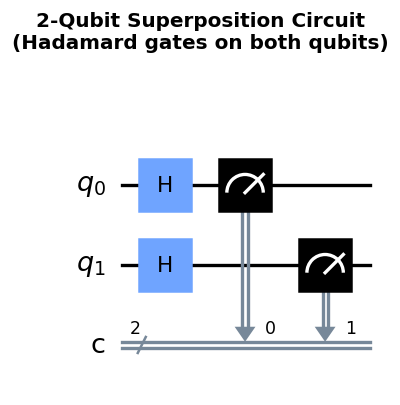

In [4]:
# ─── Draw Circuit as Proper Diagram ──────────────────────────────────────────
# Screenshot this for your report!

fig = qc.draw(output='mpl', style='clifford')
fig.set_size_inches(9.5, 3.4)
fig.suptitle('2-Qubit Superposition Circuit\n(Hadamard gates on both qubits)',
             fontsize=12, fontweight='bold', y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.90])
display(fig)
plt.close(fig)

In [5]:
# ─── Run on Local Simulator ───────────────────────────────────────────────────

# Create the Aer simulator — this is IBM's local quantum simulator
simulator = AerSimulator()

# Transpile converts our circuit into simulator-compatible instructions
compiled = transpile(qc, simulator)

# Run 1000 times (1000 "shots") — each run is one measurement
job = simulator.run(compiled, shots=1000)
result = job.result()

# Get counts — how many times each outcome appeared
counts = result.get_counts()

print("Measurement Results after 1000 shots:")
print("=" * 42)
for state, count in sorted(counts.items()):
    pct = count / 10
    bar = '█' * int(pct / 2)
    print(f"  |{state}⟩ : {count:4d} times  ({pct:5.1f}%)  {bar}")
print("=" * 42)
print("Expected: ~25.0% each (250 each)")
print("\nConclusion: Equal distribution across all 4 states")
print("proves both qubits were in genuine superposition.")


Measurement Results after 1000 shots:
  |00⟩ :  229 times  ( 22.9%)  ███████████
  |01⟩ :  265 times  ( 26.5%)  █████████████
  |10⟩ :  225 times  ( 22.5%)  ███████████
  |11⟩ :  281 times  ( 28.1%)  ██████████████
Expected: ~25.0% each (250 each)

Conclusion: Equal distribution across all 4 states
proves both qubits were in genuine superposition.


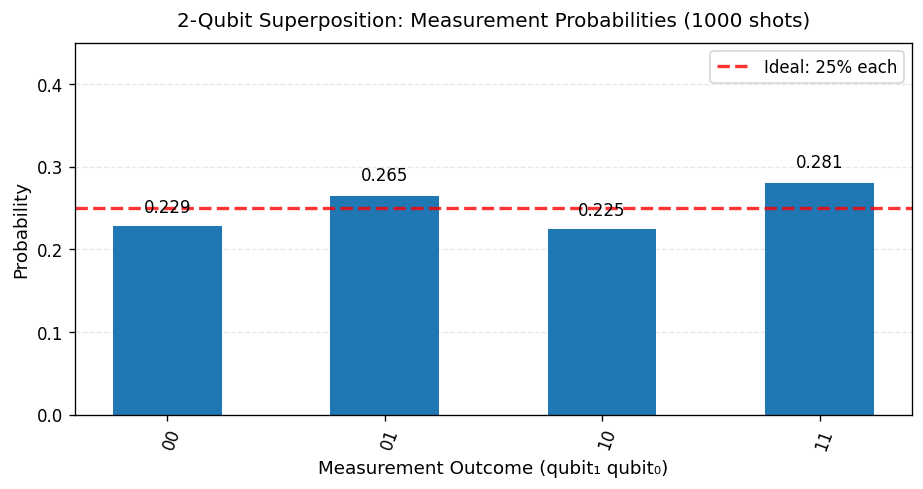

In [6]:
# ─── Histogram Visualization ─────────────────────────────────────────────────
# This is the main plot — screenshot it for your report!

fig, ax = plt.subplots(figsize=(7.8, 4.4))

prob_counts = {state: counts.get(state, 0) / 1000 for state in ['00', '01', '10', '11']}

# Qiskit's built-in histogram function with probabilities
plot_histogram(prob_counts, ax=ax)
ax.set_title('2-Qubit Superposition: Measurement Probabilities (1000 shots)', fontsize=12, pad=10)

# Red dashed line = theoretical expected value
ax.axhline(y=0.25, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Ideal: 25% each')
ax.set_xlabel('Measurement Outcome (qubit₁ qubit₀)', fontsize=11)
ax.set_ylabel('Probability', fontsize=11)
ax.set_ylim(0, 0.45)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

fig.tight_layout(rect=[0, 0, 1, 0.95])
display(fig)
plt.close(fig)

---
## Part 2: Bell State — Demonstrating Entanglement

A **Bell State** is the simplest entangled quantum state. After applying H + CNOT:

```
|Φ+⟩ = (1/√2)(|00⟩ + |11⟩)
```

The two qubits are now perfectly correlated — you can **only** measure |00⟩ or |11⟩. Never |01⟩ or |10⟩.  
This is entanglement: the qubits are linked regardless of distance.

In [7]:
# ─── Build Bell State Circuit ─────────────────────────────────────────────────

bell = QuantumCircuit(2, 2)

# Step 1: Hadamard on qubit 0 — creates superposition
bell.h(0)

# Step 2: CNOT gate — qubit 0 controls qubit 1
# If qubit 0 = |1⟩, flip qubit 1. This creates entanglement.
bell.cx(0, 1)

# Measure both
bell.measure([0, 1], [0, 1])

print("Bell State Circuit (text):")
print(bell.draw(output='text', fold=80))


Bell State Circuit (text):
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


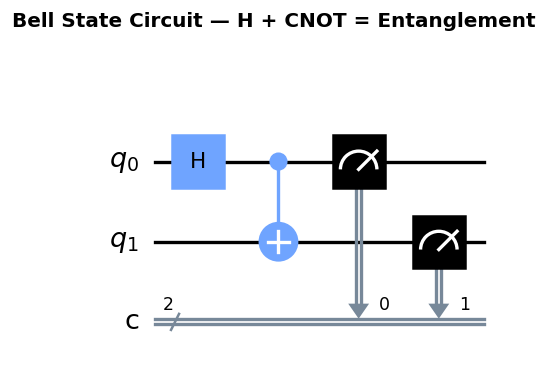

In [8]:
# Draw Bell circuit
fig2 = bell.draw(output='mpl', style='clifford')
fig2.set_size_inches(9.5, 3.2)
fig2.suptitle('Bell State Circuit — H + CNOT = Entanglement', fontsize=12, fontweight='bold', y=0.98)
fig2.tight_layout(rect=[0, 0, 1, 0.90])
display(fig2)
plt.close(fig2)

In [9]:
# ─── Simulate Bell State ──────────────────────────────────────────────────────

compiled_bell = transpile(bell, simulator)
bell_result   = simulator.run(compiled_bell, shots=1000).result()
bell_counts   = bell_result.get_counts()

print("Bell State Measurement Results (1000 shots):")
print("=" * 45)
for state in ['00', '01', '10', '11']:
    count = bell_counts.get(state, 0)
    pct   = count / 10
    bar   = '█' * int(pct / 2)
    print(f"  |{state}⟩ : {count:4d} times  ({pct:5.1f}%)  {bar}")
print("=" * 45)
print("NOTICE: |01⟩ and |10⟩ = 0% (never appear)")
print("Only |00⟩ and |11⟩ appear — this is ENTANGLEMENT!")
print("The qubits are always in the same state when measured.")


Bell State Measurement Results (1000 shots):
  |00⟩ :  501 times  ( 50.1%)  █████████████████████████
  |01⟩ :    0 times  (  0.0%)  
  |10⟩ :    0 times  (  0.0%)  
  |11⟩ :  499 times  ( 49.9%)  ████████████████████████
NOTICE: |01⟩ and |10⟩ = 0% (never appear)
Only |00⟩ and |11⟩ appear — this is ENTANGLEMENT!
The qubits are always in the same state when measured.


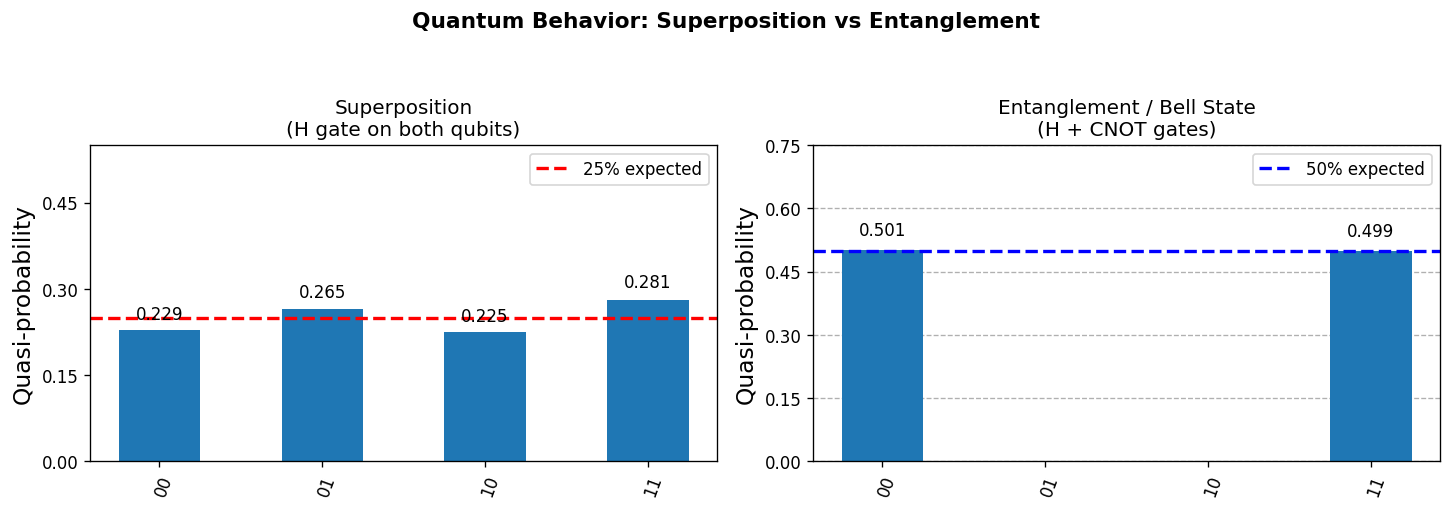

In [10]:
# ─── Side-by-Side: Superposition vs Entanglement ─────────────────────────────
# Great visual to screenshot for report!

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.3))
fig.suptitle('Quantum Behavior: Superposition vs Entanglement',
             fontsize=13, fontweight='bold', y=0.98)

super_prob = {state: counts.get(state, 0) / 1000 for state in ['00', '01', '10', '11']}
bell_prob  = {state: bell_counts.get(state, 0) / 1000 for state in ['00', '01', '10', '11']}

# Left — superposition: 4 equal bars
plot_histogram(super_prob, ax=axes[0])
axes[0].set_title('Superposition\n(H gate on both qubits)')
axes[0].axhline(y=0.25, color='red', linestyle='--', linewidth=2, label='25% expected')
axes[0].set_ylim(0, 0.55)
axes[0].legend()

# Right — entanglement: only |00⟩ and |11⟩
plot_histogram(bell_prob, ax=axes[1])
axes[1].set_title('Entanglement / Bell State\n(H + CNOT gates)')
axes[1].axhline(y=0.50, color='blue', linestyle='--', linewidth=2, label='50% expected')
axes[1].set_ylim(0, 0.75)
axes[1].legend()

fig.tight_layout(rect=[0, 0, 1, 0.92])
display(fig)
plt.close(fig)

---
## Part 3: Quantum Computing Advantage — Visual Comparison

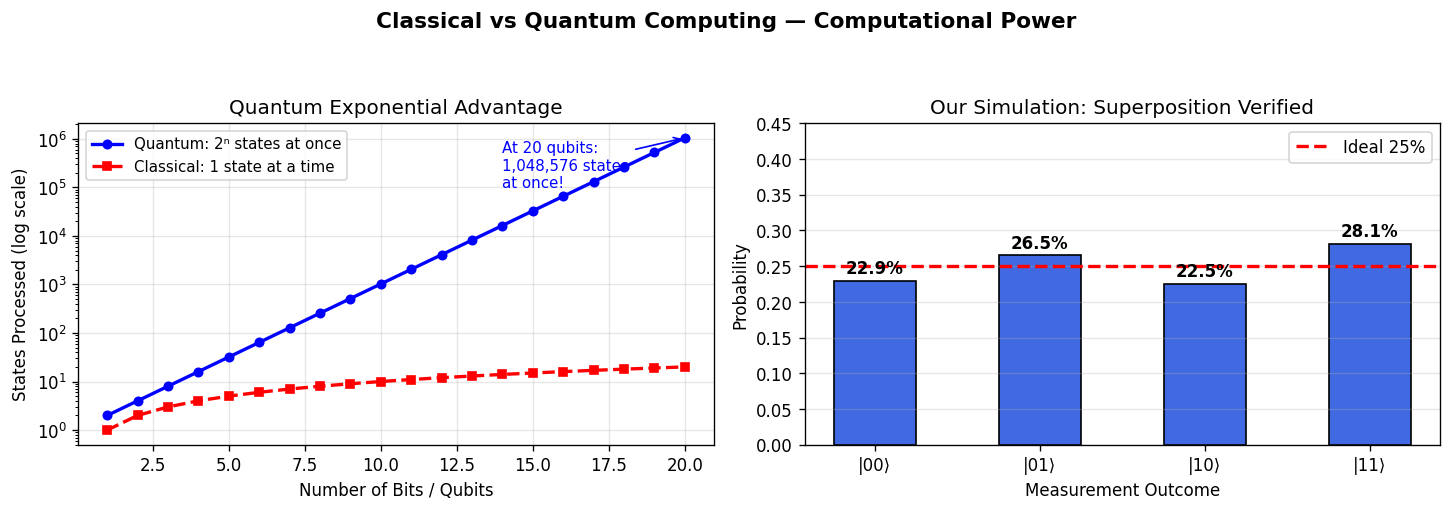

In [11]:
# ─── Classical vs Quantum: State Space Comparison ────────────────────────────
# Shows the exponential advantage of quantum over classical computing

n         = np.arange(1, 21)         # 1 to 20 bits/qubits
classical = n                        # classical: one state at a time
quantum   = 2 ** n                   # quantum: 2^n states simultaneously

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.3))
fig.suptitle('Classical vs Quantum Computing — Computational Power',
             fontsize=13, fontweight='bold', y=0.98)

# Left: exponential growth of states
axes[0].semilogy(n, quantum,   'b-o', linewidth=2, markersize=5, label='Quantum: 2ⁿ states at once')
axes[0].semilogy(n, classical, 'r--s', linewidth=2, markersize=5, label='Classical: 1 state at a time')
axes[0].set_xlabel('Number of Bits / Qubits')
axes[0].set_ylabel('States Processed (log scale)')
axes[0].set_title('Quantum Exponential Advantage')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('At 20 qubits:\n1,048,576 states\nat once!',
                 xy=(20, 2**20), xytext=(14, 1e5),
                 arrowprops=dict(arrowstyle='->', color='blue'),
                 fontsize=9, color='blue')

# Right: our actual results as bar chart
labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
probs  = [counts.get(s, 0)/1000 for s in ['00', '01', '10', '11']]
colors = ['royalblue'] * 4

bars = axes[1].bar(labels, probs, color=colors, edgecolor='black', width=0.5)
axes[1].axhline(y=0.25, color='red', linestyle='--', linewidth=2, label='Ideal 25%')
axes[1].set_xlabel('Measurement Outcome')
axes[1].set_ylabel('Probability')
axes[1].set_title('Our Simulation: Superposition Verified')
axes[1].set_ylim(0, 0.45)
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

for bar, prob in zip(bars, probs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.tight_layout(rect=[0, 0, 1, 0.92])
display(fig)
plt.close(fig)

In [12]:
# ─── Final Summary ────────────────────────────────────────────────────────────

print("=" * 60)
print("       ACTIVITY 3 — RESULTS SUMMARY")
print("=" * 60)
print()
print("EXPERIMENT 1: 2-Qubit Superposition")
print("-" * 40)
for state in ['00', '01', '10', '11']:
    count = counts.get(state, 0)
    print(f"  |{state}⟩ : {count:4d}/1000 = {count/10:5.1f}%")
print("  Expected each: ~25.0%  ✓")
print()
print("EXPERIMENT 2: Bell State (Entanglement)")
print("-" * 40)
for state in ['00', '01', '10', '11']:
    count = bell_counts.get(state, 0)
    print(f"  |{state}⟩ : {count:4d}/1000 = {count/10:5.1f}%")
print("  |01⟩ and |10⟩ = 0% confirms entanglement  ✓")
print()
print("KEY INSIGHTS:")
print("  1. Hadamard gates create genuine quantum superposition.")
print("  2. Superposition → equal probability for all 4 outcomes.")
print("  3. CNOT + H = Bell State → qubits always measured together.")
print("  4. These primitives are the building blocks of Quantum ML.")
print("  5. n qubits = 2^n states processed in parallel.")
print("=" * 60)


       ACTIVITY 3 — RESULTS SUMMARY

EXPERIMENT 1: 2-Qubit Superposition
----------------------------------------
  |00⟩ :  229/1000 =  22.9%
  |01⟩ :  265/1000 =  26.5%
  |10⟩ :  225/1000 =  22.5%
  |11⟩ :  281/1000 =  28.1%
  Expected each: ~25.0%  ✓

EXPERIMENT 2: Bell State (Entanglement)
----------------------------------------
  |00⟩ :  501/1000 =  50.1%
  |01⟩ :    0/1000 =   0.0%
  |10⟩ :    0/1000 =   0.0%
  |11⟩ :  499/1000 =  49.9%
  |01⟩ and |10⟩ = 0% confirms entanglement  ✓

KEY INSIGHTS:
  1. Hadamard gates create genuine quantum superposition.
  2. Superposition → equal probability for all 4 outcomes.
  3. CNOT + H = Bell State → qubits always measured together.
  4. These primitives are the building blocks of Quantum ML.
  5. n qubits = 2^n states processed in parallel.


---
## Section 5: Challenges and Future of Quantum ML

### Current Challenges

1. **Limited qubits** — Today's best quantum computers have ~1000 physical qubits. Practical ML needs millions.
2. **Noise and decoherence** — Qubits are fragile. Vibration, heat, or electromagnetic interference destroys the quantum state before computation finishes. This is called decoherence.
3. **Error rates** — Current NISQ (Noisy Intermediate-Scale Quantum) devices have error rates of 0.1–1% per gate. Stacking many gates amplifies errors.
4. **Scalability** — Simulating even 50 qubits classically requires more RAM than exists on Earth.

### Why Hybrid Models Are Used Today

Since full quantum ML is not practical yet, **Quantum-Classical Hybrid Models** are the current approach:
- **Classical computer**: data loading, preprocessing, gradient computation
- **Quantum processor**: core optimization step (variational circuit)
- Tools like **PennyLane** and **Qiskit Machine Learning** make this easy to implement

### Connection to ML/DL: Variational Quantum Circuits (VQC)

Our superposition circuit is the seed of a **Variational Quantum Circuit** — the standard QML model:

| Step | What it does | Classical Equivalent |
|------|-------------|---------------------|
| Data encoding (Rx, Ry gates) | Encode input features into qubit angles | Input layer |
| Parameterized gates (trainable angles) | Model weights | Hidden layer weights |
| Entangling layers (CNOT gates) | Feature interactions | Fully connected layer |
| Measurement | Prediction output | Output layer |
| Classical optimizer (Adam) | Updates gate angles to minimize loss | Backpropagation |

### Future Outlook
- **2030s**: Fault-tolerant quantum computers with millions of logical qubits
- **Quantum Kernel Methods** may outperform classical SVMs for specific high-dimensional datasets
- **Quantum Neural Networks** could potentially train exponentially faster than classical deep learning
- **Drug discovery, cryptography, financial optimization** — first industries to benefit

---
## Conclusion

In this activity we:
- Learned the core quantum concepts: superposition, entanglement, and quantum gates
- Built a **2-qubit superposition circuit** using Qiskit and verified the equal 25% distribution across all 4 outcomes
- Built a **Bell State** circuit and confirmed entanglement — only |00⟩ and |11⟩ appeared
- Connected these quantum primitives to **Quantum Machine Learning** — data encoding, parallel computation, and hybrid optimization
- Visualized the **exponential advantage** of quantum over classical computing

Quantum computing is still early-stage, but Qiskit makes it accessible today. These foundations — superposition, entanglement, and measurement — are the building blocks of tomorrow's AI.